# Greedy String Art

Preprocess a target image, precalc the line matrix, then greedily select lines to approximate it.

In [1]:
import matrix
import greedy
from preprocess import circle_crop
from PIL import Image
from importlib import reload
import matplotlib.pyplot as plt
import numpy as np

reload(matrix)
reload(greedy)

<module 'greedy' from '/Users/jackstanley/Documents/VSCode/VSCode_old/string_draw/greedy.py'>

## Settings

Edit image path, resolution, peg count, and line budget here.

In [ ]:
H = 256
P = 120
LINE_WIDTH = 0.08
MAX_LINES = 6000
CIRCLE_PADDING = 32
IMAGE_PATH = 'tiger2.jpg'

## Preprocess target

Crop to a circle on a white background and convert to grayscale.

(256, 256)


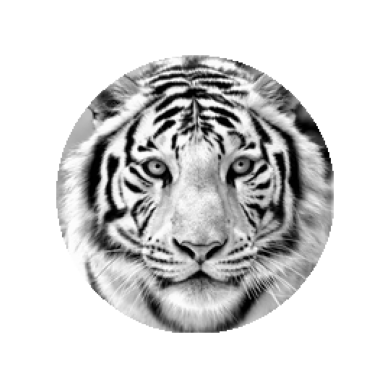

In [3]:
target = Image.open(IMAGE_PATH)
target = circle_crop(target, H, CIRCLE_PADDING).convert('L')
print(np.array(target).shape)

plt.imshow(target, cmap='gray')
plt.axis('off')
plt.show()

## Precalc line matrix

Build the antialiased darkness matrix `M` (one column per peg-to-peg line).

In [4]:
M = matrix.precalc(H, P, line_width=LINE_WIDTH, sparse=False)
print('M shape:', M.shape)

initializing matrix of size 467927040


100%|██████████| 120/120 [00:00<00:00, 248.22it/s]


M shape: (65536, 7140)


## Greedy solve

Select lines one at a time (binary 0/1) to minimize MSE against the target.

In [5]:
x, selected = greedy.greedy_solve(
    M,
    np.array(target),
    H,
    max_lines=MAX_LINES,
    line_width=LINE_WIDTH,
    verbose=True,
)

print(f'Selected {len(selected)} lines')

greedy:  84%|████████▍ | 6000/7140 [08:25<01:36, 11.87it/s, lines=6000, mse=32635.5]

Selected 6000 lines


## Render result

Compare the target with the greedy reconstruction.

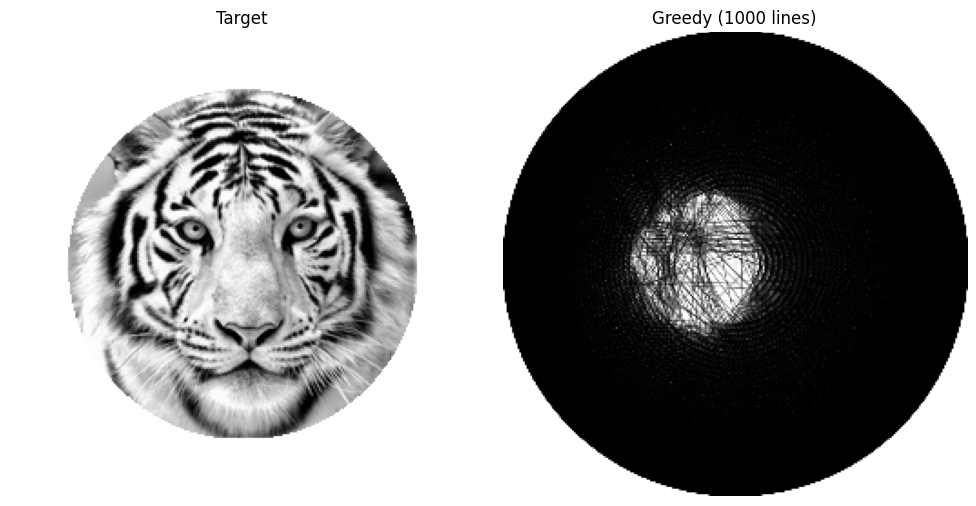

In [7]:
result = matrix.render_image(M, x, H, threshold=0.5, line_width=LINE_WIDTH)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(target, cmap='gray')
axes[0].set_title('Target')
axes[0].axis('off')

axes[1].imshow(result, cmap='gray')
axes[1].set_title(f'Greedy ({len(selected[:1000])} lines)')
axes[1].axis('off')

plt.tight_layout()
plt.show()